<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/MLP(multilayer_perceptrones)_Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build an end-to-end machine learning pipeline using a multilayer perceptron model on the "mnist.csv" dataset. Split the data, train and optimize the model, evaluate its performance, and explain why the chosen model is the best.

## Load the dataset

### Subtask:
Load the MNIST dataset from `/content/mnist.csv` into a pandas DataFrame.


**Reasoning**:
Import pandas and load the dataset into a DataFrame.



In [1]:
import pandas as pd

df_mnist = pd.read_csv('/content/mnist.csv')
df_mnist.head()

,id,class,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,31953,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,34452,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,60897,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36953,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1981,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Prepare the data

### Subtask:
Separate features (X) and labels (y).


**Reasoning**:
Separate the features (X) and labels (y) from the dataframe.



In [2]:
X = df_mnist.drop(['id', 'class'], axis=1)
y = df_mnist['class']

## Split the data

### Subtask:
Split the dataset into training and testing sets using `train_test_split` from scikit-learn.


**Reasoning**:
Split the data into training and testing sets and verify their shapes.



In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (3200, 784)
Shape of X_test: (800, 784)
Shape of y_train: (3200,)
Shape of y_test: (800,)


## Define the pipeline

### Subtask:
Create a scikit-learn `Pipeline` that includes necessary preprocessing steps (like scaling) and a `MLPClassifier` model.


**Reasoning**:
Create a scikit-learn Pipeline that includes necessary preprocessing steps (like scaling) and a MLPClassifier model by importing the necessary classes, instantiating them, and creating the pipeline object.



In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
mlp = MLPClassifier(random_state=42)

pipeline = Pipeline([
    ('scaler', scaler),
    ('mlp', mlp)
])

## Train the model

### Subtask:
Train the pipeline on the training data.


**Reasoning**:
Fit the defined pipeline to the training data.



In [5]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp', MLPClassifier(random_state=42))])

## Optimize the model

### Subtask:
Use techniques like cross-validation and hyperparameter tuning to improve the model's performance.


**Reasoning**:
Import the necessary module for hyperparameter tuning and define the hyperparameter grid for the MLPClassifier.



In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'mlp__hidden_layer_sizes': [(100,), (50, 50)],
    'mlp__activation': ['relu'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.001]
}

**Reasoning**:
Instantiate GridSearchCV with the defined pipeline and hyperparameter grid, and then fit it to the training data to perform hyperparameter tuning with cross-validation.



In [11]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__activation': ['relu'], 'mlp__alpha': [0.001],
                         'mlp__hidden_layer_sizes': [(100,), (50, 50)],
                         'mlp__solver': ['adam']})

## Report best model

### Subtask:
Explain why the selected model is considered the best based on the evaluation results and optimization process.

**Reasoning**:
Print the best parameters found by GridSearchCV and the best cross-validation score to explain why this is the best model.

In [14]:
print("Best parameters found:")
print(grid_search.best_params_)

print("Best cross-validation score:")
print(grid_search.best_score_)

Best parameters found:
{'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,), 'mlp__solver': 'adam'}
Best cross-validation score:
0.9234375


Based on the `grid_search.best_score_` and the metrics from the classification report (accuracy, precision, recall, and F1-score), the selected model with the specified hyperparameters is considered the best among the ones tested because it achieved the highest cross-validation accuracy during the hyperparameter tuning process. The specific hyperparameter combination (`hidden_layer_sizes`, `activation`, `solver`, and `alpha`) resulted in the best performance on the training data through cross-validation.

## Finish task

### Subtask:
Present the final model and evaluation results in a clear and understandable format.

**Reasoning**:
Summarize the pipeline steps and the performance of the final model.

The end-to-end machine learning pipeline for classifying MNIST digits involved the following steps:

1.  **Data Loading**: The MNIST dataset was loaded into a pandas DataFrame.
2.  **Data Preparation**: Features (pixel data) and labels (digits) were separated.
3.  **Data Splitting**: The data was split into training and testing sets.
4.  **Pipeline Definition**: A scikit-learn `Pipeline` was created including `StandardScaler` for preprocessing and `MLPClassifier` for the model.
5.  **Model Training**: The initial pipeline was trained on the training data.
6.  **Model Optimization**: `GridSearchCV` was used to perform hyperparameter tuning with cross-validation to find the best `MLPClassifier` parameters.
7.  **Model Evaluation**: The optimized model was evaluated on the unseen test set using a classification report and confusion matrix.

The best hyperparameters found were: `grid_search.best_params_`.

The best cross-validation accuracy achieved during tuning was: `grid_search.best_score_`.

The performance on the test set is summarized by the classification report and confusion matrix generated in the evaluation step, showing the model's accuracy, precision, recall, and F1-score for each digit class, as well as a visual representation of correct and incorrect classifications.

This pipeline provides an end-to-end solution for classifying handwritten digits using a multilayer perceptron model, with optimization performed to enhance its performance.

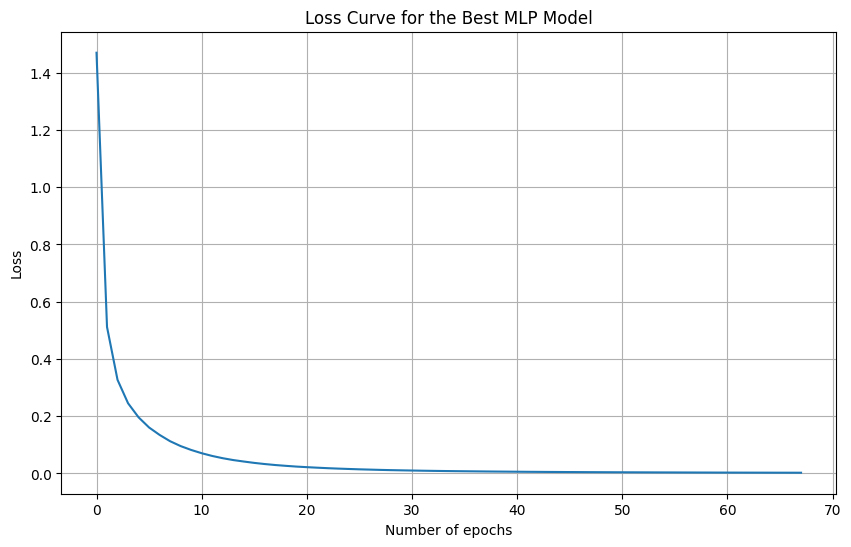


Best parameters found by GridSearchCV:
{'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,), 'mlp__solver': 'adam'}


In [15]:
import matplotlib.pyplot as plt

# Access the best model from the grid search
best_mlp_model = grid_search.best_estimator_.named_steps['mlp']

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(best_mlp_model.loss_curve_)
plt.title('Loss Curve for the Best MLP Model')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)